In [1]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
# fetch dataset 
nursery = fetch_ucirepo(id=76) 

In [2]:
# Check what was loaded
print(nursery.metadata.name)
print(nursery.metadata.abstract)
print("Rows:", nursery.metadata.num_instances)
print("Columns:", nursery.metadata.num_features)

Nursery
 Nursery Database was derived from a hierarchical decision model originally developed to rank applications for nursery schools.
Rows: 12960
Columns: 8


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Get full dataset (features + target together)
df = nursery.data.original

print(df.shape)
df


(12960, 9)


,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


In [5]:
df.has_nurs.unique()

array(['proper', 'less_proper', 'improper', 'critical', 'very_crit'],
      dtype=object)

In [ ]:
df.children.unique()

array(['1', '2', '3', 'more'], dtype=object)

In [ ]:
df.finance.unique()

array(['convenient', 'inconv'], dtype=object)

In [ ]:
df.social.unique()

array(['nonprob', 'slightly_prob', 'problematic'], dtype=object)

In [ ]:
df.housing.unique()

array(['convenient', 'less_conv', 'critical'], dtype=object)

In [ ]:
df.health.unique()

array(['recommended', 'priority', 'not_recom'], dtype=object)

In [6]:
df

,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


In [9]:
df['class'].unique()


array(['recommend', 'priority', 'not_recom', 'very_recom', 'spec_prior'],
      dtype=object)

### EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   parents   12960 non-null  object
 1   has_nurs  12960 non-null  object
 2   form      12960 non-null  object
 3   children  12960 non-null  object
 4   housing   12960 non-null  object
 5   finance   12960 non-null  object
 6   social    12960 non-null  object
 7   health    12960 non-null  object
 8   class     12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [11]:
df.shape

(12960, 9)

In [12]:
### Check missing values
df.isnull().sum()

parents     0
has_nurs    0
form        0
children    0
housing     0
finance     0
social      0
health      0
class       0
dtype: int64

In [13]:
## Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


parents: 3 unique values
has_nurs: 5 unique values
form: 4 unique values
children: 4 unique values
housing: 3 unique values
finance: 2 unique values
social: 3 unique values
health: 3 unique values
class: 5 unique values


In [14]:
df['class'].value_counts(normalize=True)


class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025309
recommend     0.000154
Name: proportion, dtype: float64

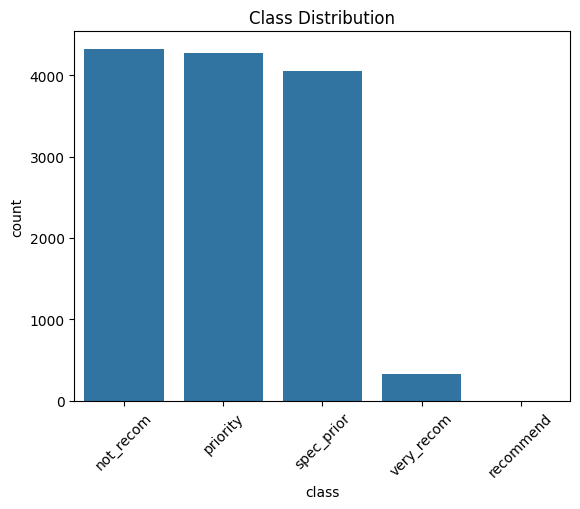

In [16]:
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()


In [18]:
df['class'] = df['class'].replace({'recommend': 'very_recom'}) # Merge recommend and very_recom

In [20]:
df['class'].value_counts(normalize=True)

class
not_recom     0.333333
priority      0.329167
spec_prior    0.312037
very_recom    0.025463
Name: proportion, dtype: float64